In [1]:
from maze_nca.config import EnvConfig
from maze_nca.nca import NCAModel
from maze_nca.task_generation import generate_task, generate_batch
from maze_nca.utils import plot_channel, benchmark_reward
from maze_nca.train import train_loop
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW

## Visualizing Task Channels

In [ ]:
# Visualize Channels
sim_config = EnvConfig()
ca = NCAModel(
    config = sim_config.to_tf_nca_cfg()
)
env = generate_task(
    sim_config.to_tf_task_cfg(),
    seed=tf.constant([1, 1], tf.int32)
)
env = ca.egg(env)
plot_channel(env, -1)
plot_channel(env, -2)

## Benchmarking Reward Function

In [ ]:
sim_config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
)

ca = NCAModel(config = sim_config.to_tf_nca_cfg())

benchmark_reward(
    sim_config,
    ca,
    batch_size=10,
    base_seed=tf.constant([1, 1], tf.int32)
)

## Testing NCA Behavior

In [ ]:
sim_config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
    death_threshold=0.001,
    avg_signal_threshold=0.001,
    live_init=1.0
)
task_cfg = sim_config.to_tf_task_cfg()
nca_cfg = sim_config.to_tf_nca_cfg()

ca = NCAModel(config=nca_cfg)

tasks = generate_batch(
    tf_task_cfg = task_cfg,
    batch_size = 10,
    task_shape = sim_config.get_task_shape(),
    base_seed = tf.constant([1, 1], dtype=tf.int32)
)

In [ ]:
seed = tf.constant([1, 1], tf.int32)

world = ca.egg(tasks)
plot_channel(world[0, ...], 0)

for _ in range(3):
    world = ca(
        world=world,
        seed=seed
    )
    
    plot_channel(world[0, ...], 0)

# Testing BPTT

In [14]:
sim_config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
    death_threshold=0.001,
    avg_signal_threshold=0.001,
    live_init=1.0,
    epochs=3,
    rollout_steps=10
)
task_cfg = sim_config.to_tf_task_cfg()
nca_cfg = sim_config.to_tf_nca_cfg()

ca = NCAModel(config=nca_cfg)

tasks = generate_batch(
    tf_task_cfg = task_cfg,
    batch_size = 10,
    task_shape = sim_config.get_task_shape(),
    base_seed = tf.constant([1, 1], dtype=tf.int32)
)

optimizer = AdamW(
    learning_rate=sim_config.lr,
    weight_decay=sim_config.weight_decay
)
optimizer.build(ca.trainable_variables)

In [19]:
history = train_loop(
    nca = ca,
    task = tasks,
    optimizer = optimizer,
    config = sim_config,
    seed = tf.constant([1, 1], tf.int32)
)

In [20]:
history

[<tf.Tensor: shape=(), dtype=float32, numpy=-0.0013701282441616058>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-0.0013701282441616058>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-0.0013701282441616058>]

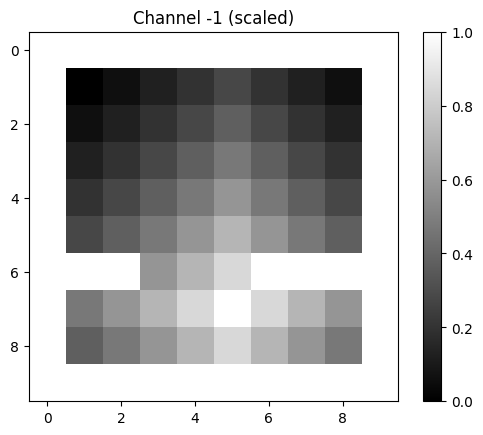

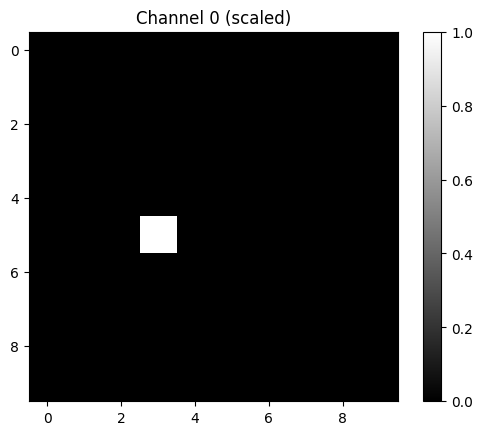

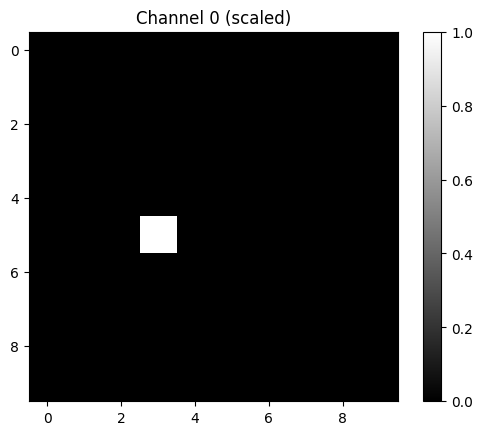

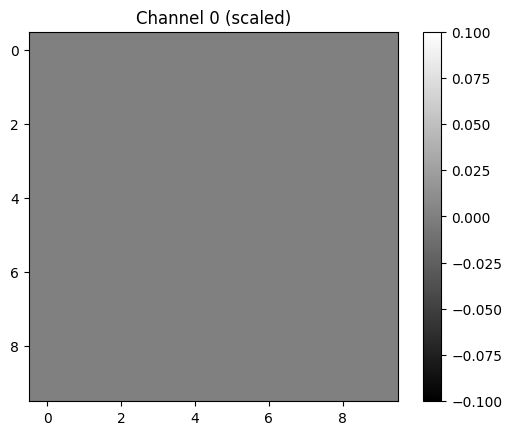

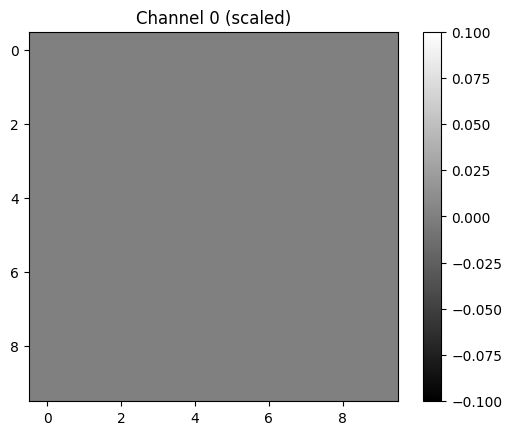

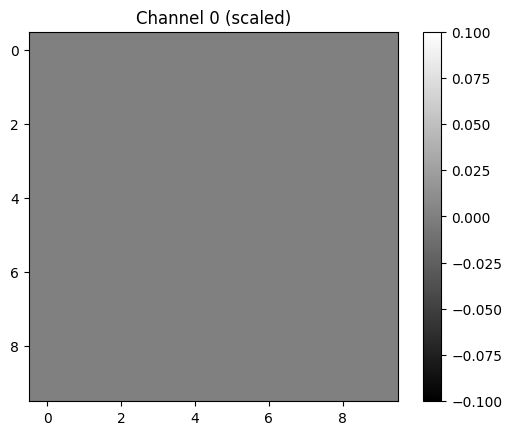

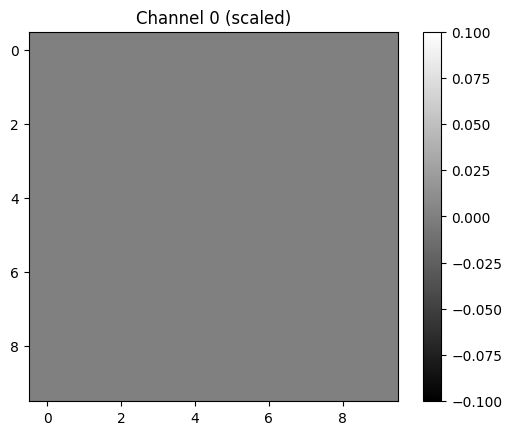

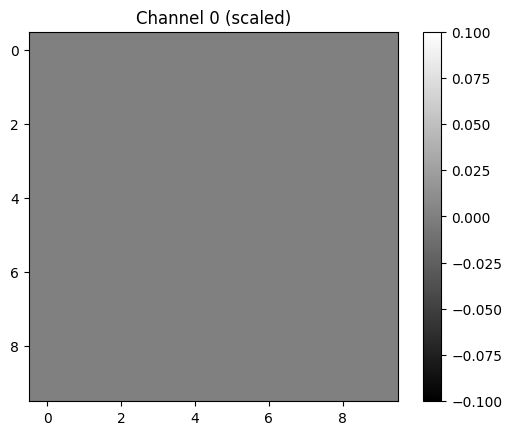

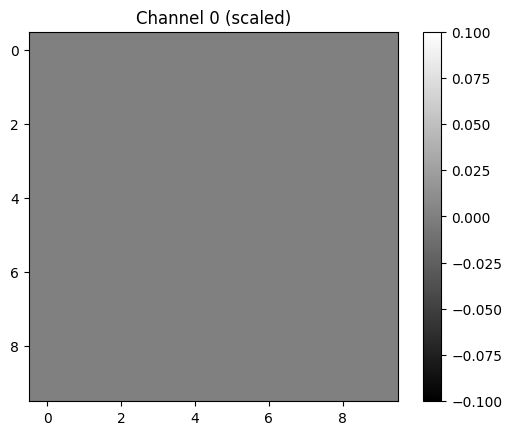

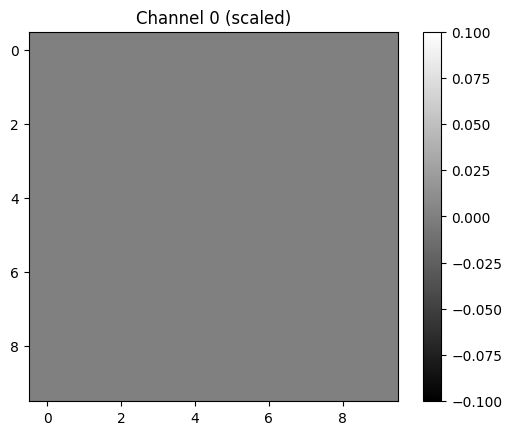

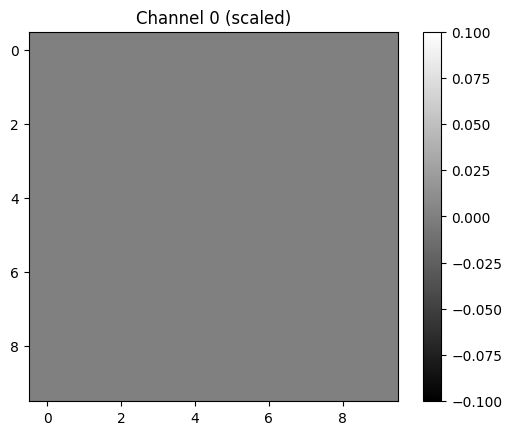

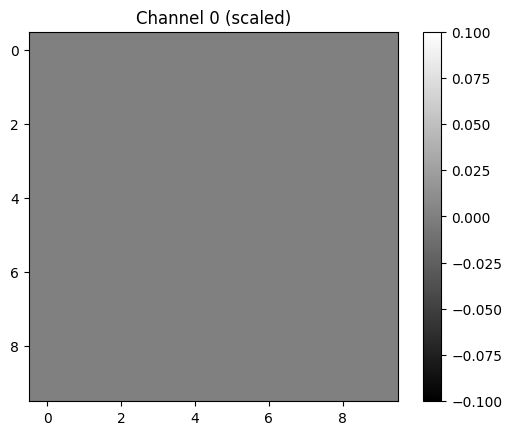

In [21]:
tasks = generate_batch(
    tf_task_cfg = task_cfg,
    batch_size = 10,
    task_shape = sim_config.get_task_shape(),
    base_seed = tf.constant([1, 1], dtype=tf.int32)
)

seed = tf.constant([1, 1], tf.int32)

world = ca.egg(tasks)
plot_channel(world[0, ...], -1)
plot_channel(world[0, ...], 0)


for _ in range(10):
    world = ca(
        world=world,
        seed=seed
    )
    
    plot_channel(world[0, ...], 0)